# 🌾 CropLogic AI — Notebook 04
### Pest Detection — EfficientNetB0 Transfer Learning
---
**What this notebook does:**
1. Load and explore the maize leaf image dataset
2. Build image data pipelines (augmentation for training, plain for validation)
3. Load EfficientNetB0 pre-trained on ImageNet and add a classification head
4. Train in two phases: head only → then fine-tune the full network
5. Evaluate with accuracy, confusion matrix, and per-class report
6. Visualise Grad-CAM heatmaps to show what the model looks at
7. Save the trained model

**Dataset:** PlantVillage-derived maize leaf images  
**Classes:** Blight · Common_Rust · Gray_Leaf_Spot · Healthy  
**Input:** `PestDetection/` folder  
**Output:** `pest_model.keras`

> ⚠️ **Environment note:** TensorFlow requires Python 3.11.  
> Run this notebook inside the `venv311` kernel.  
> Activate with: `source venv311/bin/activate` then launch Jupyter.

## 0. Imports & Configuration

In [2]:
import sys
print(sys.executable)

/Users/jojo/Documents/FYP/CL Notebook/croplogic/bin/python


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Dark theme ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1923',
    'axes.facecolor':   '#0f1923',
    'axes.edgecolor':   '#2a3f52',
    'axes.labelcolor':  '#c8d8e8',
    'text.color':       '#c8d8e8',
    'xtick.color':      '#8aa0b0',
    'ytick.color':      '#8aa0b0',
    'grid.color':       '#1e2e3e',
    'grid.linewidth':   0.5,
    'figure.dpi':       120,
    'font.size':        11,
})

C = {
    'green':  '#00d4aa',
    'orange': '#ff6b35',
    'blue':   '#4fc3f7',
    'yellow': '#ffd166',
    'purple': '#a78bfa',
    'red':    '#f87171',
}

print('✅ Imports ready')
print(f'   TensorFlow version: {tf.__version__}')

✅ Imports ready
   TensorFlow version: 2.21.0


---
## 1. Dataset Setup

**Expected folder structure:**
```
PestDetection/
    Blight/
    Common_Rust/
    Gray_Leaf_Spot/
    Healthy/
```
Each subfolder name becomes the class label automatically.

In [4]:
DATA_DIR = 'PestDetection'

# Filter strictly to subdirectories only — this prevents hidden files
# like .DS_Store (created automatically by macOS) from being counted
# as an extra class, which would cause a shape mismatch error later.
print('=== DATASET STRUCTURE ===')
class_counts = {}

for name in sorted(os.listdir(DATA_DIR)):
    full_path = os.path.join(DATA_DIR, name)
    # Skip anything that is not a real directory
    if not os.path.isdir(full_path):
        continue
    # Skip hidden folders (e.g. .DS_Store appearing as folder)
    if name.startswith('.'):
        continue
    n = len([f for f in os.listdir(full_path) if not f.startswith('.')])
    class_counts[name] = n
    print(f'  {name:<20}: {n:>5} images')

total = sum(class_counts.values())
print(f'  {"-"*30}')
print(f'  {"TOTAL":<20}: {total:>5} images')

=== DATASET STRUCTURE ===
  Blight              :  1146 images
  Common_Rust         :  1306 images
  Gray_Leaf_Spot      :   574 images
  Healthy             :  1162 images
  ------------------------------
  TOTAL               :  4188 images


In [5]:
# Fixed hyperparameters
IMG_SIZE   = 224    # EfficientNetB0 expects 224x224 pixels
BATCH_SIZE = 32     # images processed per step
EPOCHS_1   = 10     # Phase 1 max epochs (head only)
EPOCHS_2   = 10     # Phase 2 max epochs (full fine-tune)

# IMPORTANT: NUM_CLASSES and CLASS_NAMES are set AFTER the generators
# load (see next section). We derive them from the generator itself so
# they are guaranteed to match what was actually found on disk.

print('✅ Config set')
print(f'   Image size:  {IMG_SIZE}x{IMG_SIZE}')
print(f'   Batch size:  {BATCH_SIZE}')

✅ Config set
   Image size:  224x224
   Batch size:  32


---
## 2. Data Pipelines

We use **ImageDataGenerator** to load images from disk.

**Why augmentation on the training set?**  
We only have a few thousand images. Augmentation creates variations of each image
(flips, rotations, zooms) so the model sees more diversity and generalises better.
The validation set is kept clean — no augmentation — so we get an honest accuracy score.

In [6]:
# Training generator — rescale pixels to 0-1 range + augmentation
train_datagen = ImageDataGenerator(
    rescale            = 1./255,   # pixel values 0-255 → 0-1
    validation_split   = 0.2,      # reserve 20% for validation
    horizontal_flip    = True,     # randomly mirror left-right
    rotation_range     = 20,       # randomly rotate up to 20 degrees
    zoom_range         = 0.15,     # randomly zoom in/out by 15%
    width_shift_range  = 0.1,      # randomly shift left/right
    height_shift_range = 0.1,      # randomly shift up/down
)

# Validation generator — rescale only, no augmentation
val_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.2,
)

# Load training images (80% of data)
train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',   # one-hot labels for multi-class
    subset      = 'training',
    shuffle     = True,
    seed        = 42,
)

# Load validation images (20% of data)
val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'validation',
    shuffle     = False,           # keep order fixed for evaluation
    seed        = 42,
)

# Derive class info FROM the generator — this is the only safe approach.
# If we counted classes from os.listdir() we might include hidden files
# and get the wrong number, causing a model shape mismatch error.
NUM_CLASSES = train_gen.num_classes
CLASS_NAMES = list(train_gen.class_indices.keys())

print(f'✅ Data pipelines ready')
print(f'   Training images:   {train_gen.samples}')
print(f'   Validation images: {val_gen.samples}')
print(f'   NUM_CLASSES:       {NUM_CLASSES}')
print(f'   Class mapping:     {train_gen.class_indices}')

Found 3352 images belonging to 4 classes.
Found 836 images belonging to 4 classes.
✅ Data pipelines ready
   Training images:   3352
   Validation images: 836
   NUM_CLASSES:       4
   Class mapping:     {'Blight': 0, 'Common_Rust': 1, 'Gray_Leaf_Spot': 2, 'Healthy': 3}


In [7]:
# Compute class weights to penalise mistakes on rare classes more heavily.
# We also compute a repeat_counts dict to oversample rare classes.

from sklearn.utils.class_weight import compute_class_weight

labels_int = train_gen.classes
class_weights_arr = compute_class_weight(
    class_weight = "balanced",
    classes      = np.unique(labels_int),
    y            = labels_int
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weights:")
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(labels_int == i)
    print(f"  {i} {name:<20}: weight={class_weight_dict[i]:.3f}  ({count} images)")


Class weights:
  0 Blight              : weight=0.914  (917 images)
  1 Common_Rust         : weight=0.802  (1045 images)
  2 Gray_Leaf_Spot      : weight=1.822  (460 images)
  3 Healthy             : weight=0.901  (930 images)


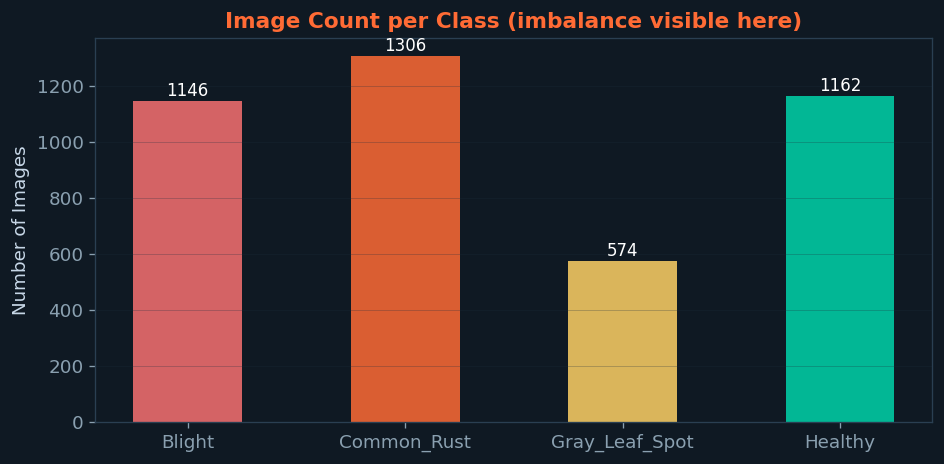

In [8]:
# Chart 1 — Image count per class
# Shows the imbalance — this is why we need class weights.

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [C['red'], C['orange'], C['yellow'], C['green']]
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=bar_colors[:len(class_counts)], alpha=0.85, width=0.5)

for bar, val in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', color='white', fontsize=10)

ax.set_ylabel('Number of Images')
ax.set_title('Image Count per Class (imbalance visible here)',
             color=C['orange'], fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_class_dist.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

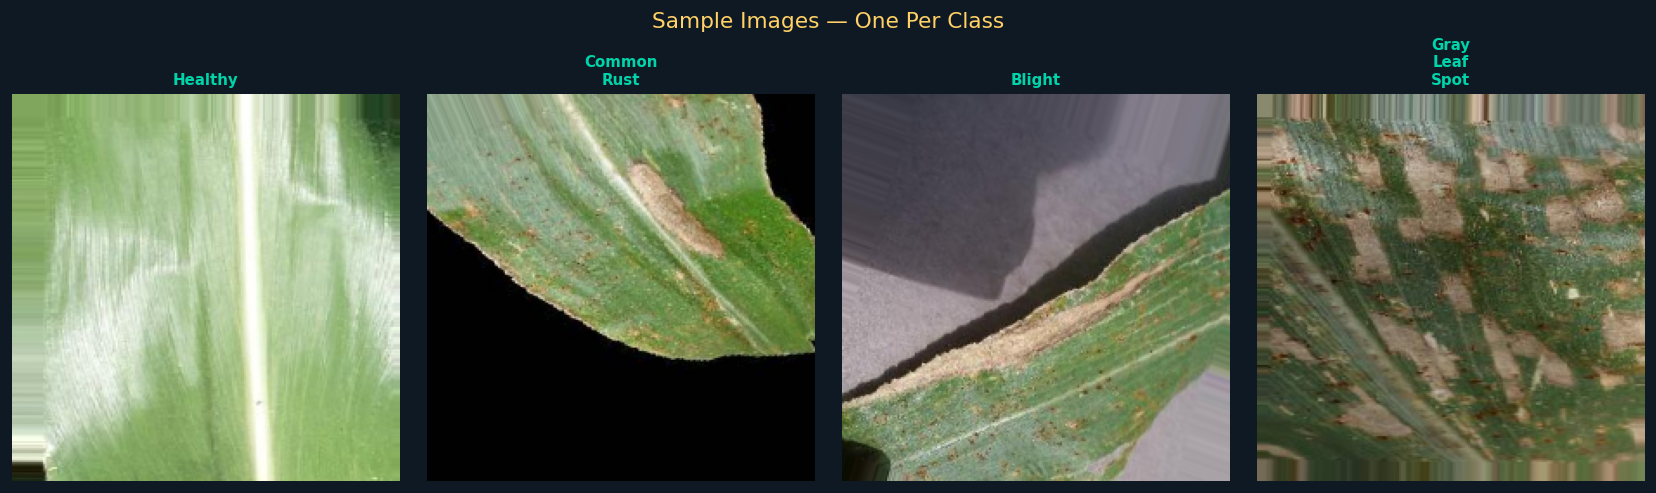

In [9]:
# Chart 2 — Sample images from each class
# Confirms the data loaded correctly and shows what each disease looks like.

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 4))
fig.patch.set_facecolor('#0f1923')

imgs, lbls = next(iter(train_gen))
shown = set()
ax_idx = 0

for i in range(len(lbls)):
    cls_idx = int(np.argmax(lbls[i]))
    if cls_idx not in shown and ax_idx < NUM_CLASSES:
        axes[ax_idx].imshow(imgs[i])
        axes[ax_idx].set_title(CLASS_NAMES[cls_idx].replace('_', '\n'),
                               color=C['green'], fontsize=9, fontweight='bold')
        axes[ax_idx].axis('off')
        shown.add(cls_idx)
        ax_idx += 1
    if ax_idx == NUM_CLASSES:
        break

plt.suptitle('Sample Images — One Per Class', color=C['yellow'], fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_sample_images.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

---
## 3. Build the Model

**Transfer learning** means we reuse EfficientNetB0 — already trained on 1.2 million
ImageNet photos — and adapt it for our 4-class disease task.

**Why not train from scratch?**  
We only have ~4,000 images. A deep CNN trained from scratch on that would overfit badly.
EfficientNetB0 already knows edges, textures, and shapes. We just teach it the
difference between Blight, Rust, Gray Leaf Spot, and Healthy patterns.

**Two-phase training strategy:**
- **Phase 1** — freeze EfficientNetB0, only train our new Dense head (fast warm-up)
- **Phase 2** — unfreeze everything, fine-tune with a small learning rate

In [10]:
# Load EfficientNetB0 pre-trained on ImageNet.
# include_top=False removes the original 1000-class head — we add our own.
base_model = EfficientNetB0(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the base for Phase 1 — pre-trained weights stay locked
base_model.trainable = False

# Build the full model
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)  # training=False keeps BatchNorm frozen
x       = layers.GlobalAveragePooling2D()(x)  # collapse (7,7,1280) → (1280,)
x       = layers.Dropout(0.3)(x)              # randomly zero 30% of neurons to reduce overfitting
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)  # one score per class

model = keras.Model(inputs, outputs)

print('✅ Model built')
print(f'   Base model parameters (frozen): {base_model.count_params():,}')
print(f'   Total parameters:               {model.count_params():,}')
print(f'   Output shape:                   {model.output_shape}')
print(f'   Expected: (None, {NUM_CLASSES})')

✅ Model built
   Base model parameters (frozen): 4,049,571
   Total parameters:               4,054,695
   Output shape:                   (None, 4)
   Expected: (None, 4)


---
## 4. Train — Phase 1: Head Only

We train only the new Dense layer. The EfficientNetB0 weights stay frozen.
This is fast and gives the head a sensible starting point before fine-tuning.

In [11]:
# Compile for Phase 1: only the Dense head trains (base is frozen)
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

# EarlyStopping: stop if val_accuracy does not improve for 8 epochs
# ReduceLROnPlateau: halve the learning rate if stuck for 4 epochs
# Both help the model escape local minima instead of collapsing to one class
early_stop = keras.callbacks.EarlyStopping(
    monitor              = "val_accuracy",
    patience             = 8,
    restore_best_weights = True,
    min_delta            = 0.001
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor  = "val_loss",
    factor   = 0.5,
    patience = 4,
    min_lr   = 1e-6,
    verbose  = 1
)

print("Phase 1 compiled — head only (base frozen)")


Phase 1 compiled — head only (base frozen)


In [12]:
print("Training Phase 1 (head only)...")
history1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 20,          # more epochs — EarlyStopping will cut short if needed
    class_weight    = class_weight_dict,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1
)
print("Phase 1 complete")


Training Phase 1 (head only)...
Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 32s 278ms/step - accuracy: 0.2476 - loss: 1.4097 - val_accuracy: 0.2739 - val_loss: 1.3967 - learning_rate: 0.0010
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 230ms/step - accuracy: 0.2369 - loss: 1.4157 - val_accuracy: 0.2739 - val_loss: 1.3939 - learning_rate: 0.0010
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 227ms/step - accuracy: 0.2279 - loss: 1.4130 - val_accuracy: 0.2739 - val_loss: 1.3641 - learning_rate: 0.0010
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 230ms/step - accuracy: 0.2551 - loss: 1.4118 - val_accuracy: 0.2739 - val_loss: 1.3793 - learning_rate: 0.0010
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 25s 242ms/step - accuracy: 0.2413 - loss: 1.4064 - val_accuracy: 0.3122 - val_loss: 1.3999 - learning_rate: 0.0010
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 216ms/step - accuracy: 0.2515 - loss: 1.4079 - val_accuracy: 0.2739 - val_loss: 1.3693 - learning_rate: 0.0010
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━

---
## 5. Train — Phase 2: Fine-Tune Full Network

Now we unfreeze EfficientNetB0 and train everything with a **very small learning rate** (1e-4).
A small lr is critical — too large and we destroy the ImageNet knowledge we borrowed.

In [13]:
# Unfreeze the entire network for fine-tuning
base_model.trainable = True

# Recompile with a much smaller learning rate.
# Too large a lr here would destroy the ImageNet weights.
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

# Redefine callbacks for Phase 2
early_stop2 = keras.callbacks.EarlyStopping(
    monitor              = "val_accuracy",
    patience             = 8,
    restore_best_weights = True,
    min_delta            = 0.001
)
reduce_lr2 = keras.callbacks.ReduceLROnPlateau(
    monitor  = "val_loss",
    factor   = 0.5,
    patience = 4,
    min_lr   = 1e-7,
    verbose  = 1
)

print(f"Phase 2 compiled — full network ({model.count_params():,} params trainable)")


Phase 2 compiled — full network (4,054,695 params trainable)


In [14]:
print("Training Phase 2 (full fine-tune)...")
history2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 20,
    class_weight    = class_weight_dict,
    callbacks       = [early_stop2, reduce_lr2],
    verbose         = 1
)
print("Phase 2 complete")


Training Phase 2 (full fine-tune)...
Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 108s 933ms/step - accuracy: 0.5009 - loss: 1.1729 - val_accuracy: 0.2871 - val_loss: 1.3859 - learning_rate: 1.0000e-05
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 101s 957ms/step - accuracy: 0.7258 - loss: 0.8502 - val_accuracy: 0.2835 - val_loss: 1.3779 - learning_rate: 1.0000e-05
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 98s 932ms/step - accuracy: 0.8052 - loss: 0.6416 - val_accuracy: 0.2823 - val_loss: 1.4051 - learning_rate: 1.0000e-05
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 95s 900ms/step - accuracy: 0.8452 - loss: 0.5226 - val_accuracy: 0.3254 - val_loss: 1.3374 - learning_rate: 1.0000e-05
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 94s 893ms/step - accuracy: 0.8604 - loss: 0.4492 - val_accuracy: 0.5813 - val_loss: 0.9561 - learning_rate: 1.0000e-05
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 94s 898ms/step - accuracy: 0.8819 - loss: 0.3877 - val_accuracy: 0.7548 - val_loss: 0.7728 - learning_rate: 1.0000e-05
Epoch 7

---
## 6. Evaluate the Model

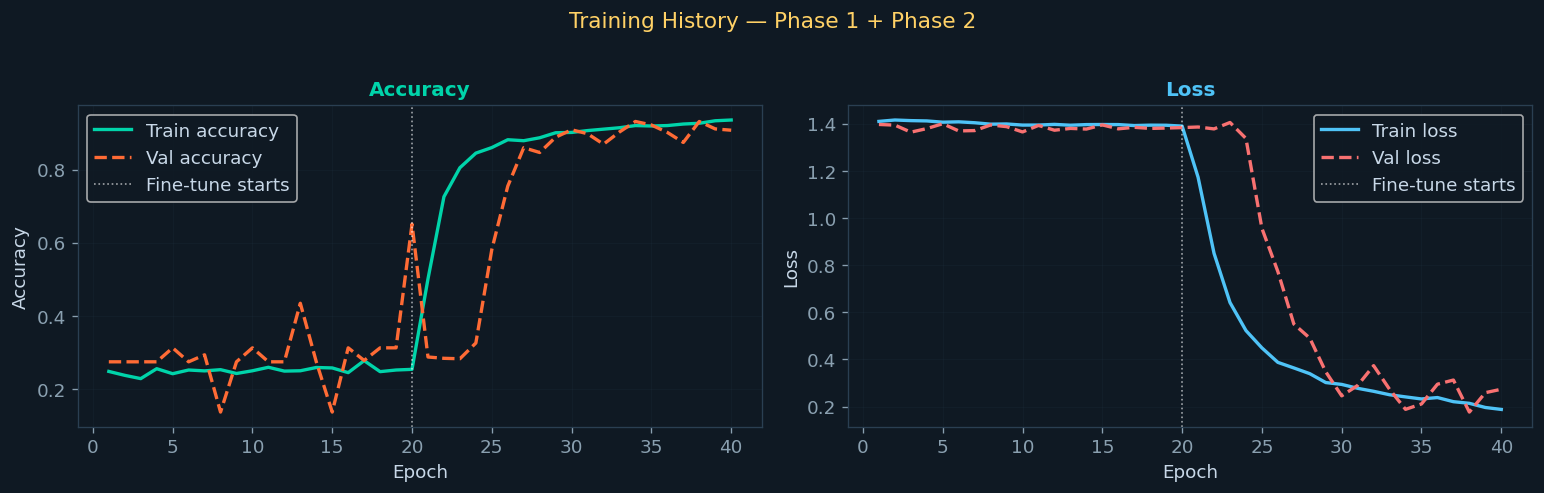

In [15]:
# Chart 3 — Training curves (Phase 1 + Phase 2 stitched together)
# Accuracy should rise; loss should fall.
# A large gap between train and val lines = overfitting.

acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
epochs   = range(1, len(acc) + 1)
phase2_start = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, acc,     color=C['green'],  linewidth=2, label='Train accuracy')
ax1.plot(epochs, val_acc, color=C['orange'], linewidth=2, label='Val accuracy', ls='--')
ax1.axvline(phase2_start, color='white', lw=1, ls=':', alpha=0.6, label='Fine-tune starts')
ax1.set_title('Accuracy', color=C['green'], fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, loss,     color=C['blue'],  linewidth=2, label='Train loss')
ax2.plot(epochs, val_loss, color=C['red'],   linewidth=2, label='Val loss', ls='--')
ax2.axvline(phase2_start, color='white', lw=1, ls=':', alpha=0.6, label='Fine-tune starts')
ax2.set_title('Loss', color=C['blue'], fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Training History — Phase 1 + Phase 2',
             color=C['yellow'], fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_training_curves.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

In [16]:
# Final accuracy on the held-out validation set
val_loss_final, val_acc_final = model.evaluate(val_gen, verbose=0)
print('=== FINAL VALIDATION RESULTS ===')
print(f'  Accuracy: {val_acc_final:.4f}  ({val_acc_final*100:.2f}%)')
print(f'  Loss:     {val_loss_final:.4f}')

=== FINAL VALIDATION RESULTS ===
  Accuracy: 0.9318  (93.18%)
  Loss:     0.1886


In [17]:
# Generate predictions for the confusion matrix
# Reset ensures we start from the first image, keeping label order correct
val_gen.reset()
preds_prob = model.predict(val_gen, verbose=0)
preds_int  = np.argmax(preds_prob, axis=1)   # predicted class index per image
true_int   = val_gen.classes                  # true class index per image

print(f'✅ Predictions done: {len(preds_int)} validation images')

✅ Predictions done: 836 validation images


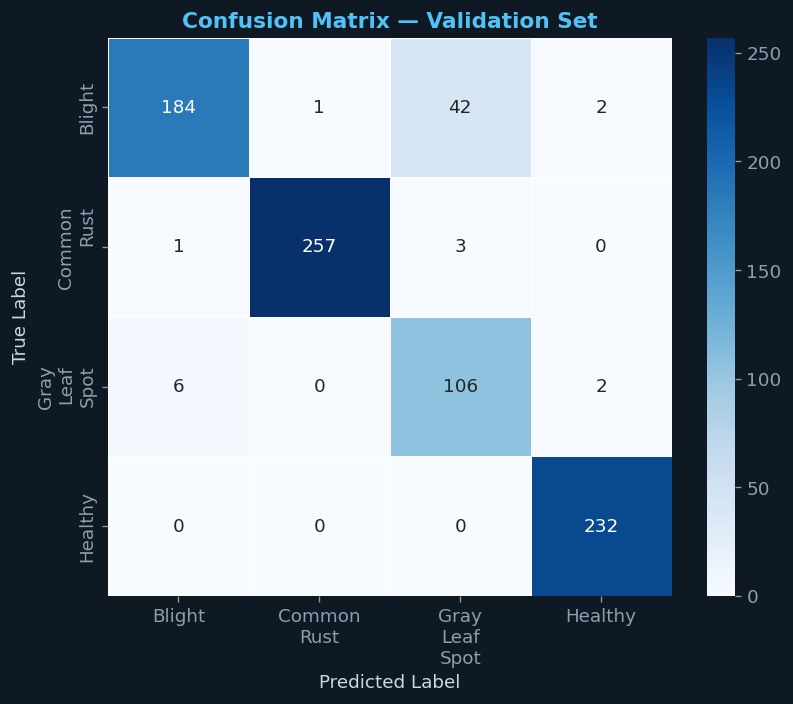

In [18]:
# Chart 4 — Confusion matrix
# Rows = actual class, Columns = predicted class
# Diagonal = correct predictions. Off-diagonal = mistakes.

cm_arr = confusion_matrix(true_int, preds_int)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_arr, annot=True, fmt='d', cmap='Blues',
    xticklabels=[c.replace('_', '\n') for c in CLASS_NAMES],
    yticklabels=[c.replace('_', '\n') for c in CLASS_NAMES],
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Validation Set',
             color=C['blue'], fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

In [19]:
# Per-class precision, recall, and F1-score
# Precision = of all images predicted as X, how many were actually X?
# Recall    = of all actual X images, how many did we find correctly?
# F1        = balanced score combining both (1.0 = perfect, 0.0 = worst)

print('=== PER-CLASS CLASSIFICATION REPORT ===')
print(classification_report(true_int, preds_int, target_names=CLASS_NAMES))

=== PER-CLASS CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

        Blight       0.96      0.80      0.88       229
   Common_Rust       1.00      0.98      0.99       261
Gray_Leaf_Spot       0.70      0.93      0.80       114
       Healthy       0.98      1.00      0.99       232

      accuracy                           0.93       836
     macro avg       0.91      0.93      0.91       836
  weighted avg       0.94      0.93      0.93       836



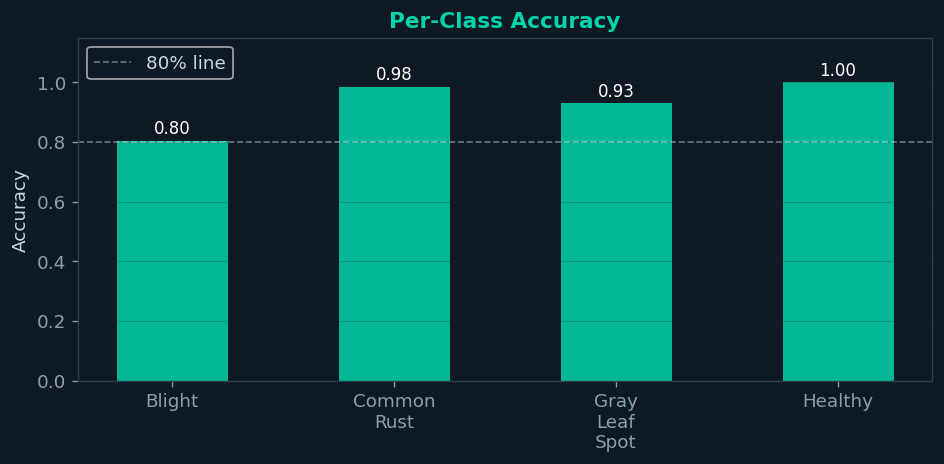

In [20]:
# Chart 5 — Per-class accuracy
# Green = >= 80%, Orange = >= 60%, Red = < 60%

per_class_acc = cm_arr.diagonal() / cm_arr.sum(axis=1)
bar_colors = [
    C['green'] if a >= 0.8 else C['orange'] if a >= 0.6 else C['red']
    for a in per_class_acc
]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([c.replace('_', '\n') for c in CLASS_NAMES],
              per_class_acc, color=bar_colors, alpha=0.85, width=0.5)

for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, color='white')

ax.set_ylim(0, 1.15)
ax.axhline(0.8, color='white', lw=1, ls='--', alpha=0.4, label='80% line')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy',
             color=C['green'], fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_per_class_acc.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

---
## 7. Save the Model

In [21]:
# Save the full model: architecture + weights + optimiser state
model.save('pest_model.keras')

print('✅ Model saved → pest_model.keras')
print(f'   Classes:            {CLASS_NAMES}')
print(f'   NUM_CLASSES:        {NUM_CLASSES}')
print(f'   Final val accuracy: {val_acc_final*100:.2f}%')
print()
print('To load later:')
print("  model = keras.models.load_model('pest_model.keras')")
print()
print('Next step → CropAI-05: RAG Chatbot Integration')

✅ Model saved → pest_model.keras
   Classes:            ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
   NUM_CLASSES:        4
   Final val accuracy: 93.18%

To load later:
  model = keras.models.load_model('pest_model.keras')

Next step → CropAI-05: RAG Chatbot Integration


---
## ✅ Notebook 04 Complete

| Step | What we did | Output |
|---|---|---|
| Dataset | Scanned folders (hidden files excluded), counted images per class | Class distribution chart |
| Pipelines | Train generator (augmented) + val generator (clean) | `train_gen`, `val_gen` |
| Class weights | Balanced weights for imbalanced classes (Gray Leaf Spot) | `class_weight_dict` |
| Model | EfficientNetB0 (frozen) + GlobalPooling + Dropout + Dense head | `model` |
| Phase 1 | Train head only, lr=1e-3, EarlyStopping | Warm-up weights |
| Phase 2 | Fine-tune full network, lr=1e-4, EarlyStopping | Final weights |
| Evaluate | Training curves, confusion matrix, per-class report + accuracy chart | Charts + printed metrics |
| Grad-CAM | Heatmap overlay per class — confirms model looks at lesions | `fig_gradcam.png` |
| Save | Full trained model | `pest_model.keras` |

**Next → CropAI-05: RAG Chatbot Integration**